### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [4]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o-mini-2024-07-18")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_33a9b387c2', 'id': 'chatcmpl-E72r5xYmi6Uco6tybrqi52mo1excJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019faf08-31c6-7fa3-904f-8aa07c5891c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3.6-27b")
llm_groq.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content="\n<think>\nHere's a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Krish\n   - Interest: Likes to play cricket\n   - Tone: Casual, friendly introduction\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the name (Krish)\n   - Acknowledge the interest (cricket)\n   - Keep it friendly and engaging\n   - Optionally ask follow-up questions to keep the conversation going\n\n3.  **Determine Response Goals:**\n   - Be welcoming\n   - Show interest in cricket\n   - Ask relevant questions to engage further\n   - Keep it concise and natural\n\n4.  **Draft Response (Mental Refinement):**\n   Hey Krish! Nice to meet you. Cricket’s a fantastic sport—love the strategy, skill, and team spirit it takes. Are you more into playing as a batsman, bowler, or all-rounder? And do you follow any particular team or league, like the IPL, international matches, or maybe local tournaments?\n\n5.  **Check Against Guidelines:**\n   - Acknowledges name? Yes\n   - Ackn

### We Will start With Creating Nodes

In [6]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

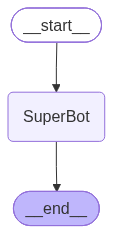

In [7]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a0042d1b-f7d5-4c98-88b8-a2f70dc47b71'),
  AIMessage(content="\n<think>\nHere's a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Krish\n   - Interest: Cricket\n   - Tone: Friendly, casual greeting\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the name (Krish)\n   - Acknowledge the interest (cricket)\n   - Maintain a friendly, engaging tone\n   - Offer to help or continue the conversation\n\n3.  **Determine Response Goals:**\n   - Greet back warmly\n   - Show enthusiasm about cricket\n   - Ask a relevant follow-up question to keep the conversation going\n   - Keep it concise and natural\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Krish! Nice to meet you. Cricket is such a fantastic sport—there's something special about the thrill of a match, whether it's a nail-biting T20 or a classic Test game. Who's your favorite team o

#### Streaming The responses

In [9]:
for event in graph_builder.stream({"messages":"Hello My name is KRish"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hello My name is KRish"\n   - Key elements: Greeting ("Hello"), Introduction ("My name is KRish")\n   - Note: Slight typo/capitalization in "KRish" (likely meant "Krish")\n\n2.  **Identify Intent:**\n   - The user is introducing themselves and greeting me.\n   - Expected response: Acknowledge the greeting, use their name, and offer assistance.\n\n3.  **Determine Response Strategy:**\n   - Be polite and friendly\n   - Acknowledge their name (correct the capitalization naturally if needed, but keep it respectful)\n   - Ask how I can help\n   - Keep it concise\n\n4.  **Draft Response (Mental):**\n   Hello Krish! Nice to meet you. How can I assist you today?\n\n5.  **Refine Response:**\n   - Check tone: Friendly, professional\n   - Check name usage: "Krish" (standard capitalization)\n   - Check purpose: Open-ended question to continue conversation\n   - Matc

In [10]:
for event in graph_builder.stream({"messages":"Hello My name is KRish"} , stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello My name is KRish', additional_kwargs={}, response_metadata={}, id='55bbd21a-0ccc-437f-a1a3-f93ad7937b4f')]}
{'messages': [HumanMessage(content='Hello My name is KRish', additional_kwargs={}, response_metadata={}, id='55bbd21a-0ccc-437f-a1a3-f93ad7937b4f'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hello My name is KRish"\n   - Key elements: Greeting ("Hello"), Name introduction ("My name is KRish")\n   - Note: "KRish" has an unusual capitalization, but it\'s clearly a name (likely "Krish" or "Krishna" shortened)\n\n2.  **Identify Intent:**\n   - The user is introducing themselves and expects a friendly, acknowledging response.\n\n3.  **Determine Response Requirements:**\n   - Acknowledge the greeting\n   - Use their name correctly\n   - Maintain a friendly, helpful tone\n   - Keep it concise\n   - Offer assistance\n\n4.  **Draft Response (Mental):**\n   Hello Krish! Nice to meet y